In [ ]:
#1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import make_scorer, f1_score, balanced_accuracy_score, accuracy_score
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.preprocessing import OrdinalEncoder
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
!pip install catboost
from catboost import CatBoostClassifier



# pd.set_option("display.max_columns", None)
# pd.set_option("display.max_rows", 100)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 10.0 MB/s eta 0:00:00


In [ ]:
#2
file_path = "/content/Dataset8.xlsx"

#  read 1st and 2nd rows and make the 1st the label and ignore the 2nd
## Discuss with Dr. because code names are better in writing code.
metadata = pd.read_excel(file_path, header=None, nrows=2)

column_codes = metadata.iloc[0].tolist()
question_labels = metadata.iloc[1].tolist()

# Read the data after ignoring the 2nd row
df = pd.read_excel(file_path, header=0, skiprows=[1])

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (145, 43)


,CASE,SERIAL,REF,QUESTNNR,MODE,LANGUAGE,STARTED,A005,A001,A002,...,A027,A027_04,STATUS,FINISHED,Q_VIEWER,LASTPAGE,MAXPAGE,MISSING,MISSREL,TIME_RSI
0,22,NaN,NaN,base,interview,ara,2026-02-26 17:04:19,"Yes, I agree",Male,2017,...,NaN,NaN,complete,1,0,7,7,0,0,0.81
1,23,NaN,NaN,base,interview,ara,2026-02-26 21:57:50,"Yes, I agree",Male,2016,...,NaN,NaN,complete,1,0,7,7,0,0,0.70
2,24,NaN,NaN,base,interview,eng,2026-02-26 21:58:38,"Yes, I agree",Male,2022,...,NaN,NaN,complete,1,0,7,7,0,0,0.31
3,26,NaN,NaN,base,interview,ara,2026-02-26 21:59:03,"Yes, I agree",Female,2009,...,NaN,NaN,complete,1,0,7,7,0,0,1.02
4,28,NaN,NaN,base,interview,ara,2026-02-26 22:09:28,"Yes, I agree",Male,2015,...,CV making.,NaN,complete,1,0,8,8,0,0,0.66


In [ ]:
#3
# create codebook to link ch column code to its full question label, which was the 2nd row, maybe I need to delete CASE column, check with additional language, vilunteer and support.
codebook = pd.DataFrame({
    "column_code": column_codes,
    "question_label": question_labels
})

codebook

,column_code,question_label
0,CASE,Interview number (sequential)
1,SERIAL,Serial number (if provided)
2,REF,Reference (if provided in link)
3,QUESTNNR,Questionnaire that has been used in the interview
4,MODE,Interview mode
5,LANGUAGE,Language
6,STARTED,Time the interview has started (Europe/Berlin)
7,A005,Consent
8,A001,Gender
9,A002,Arrival Year


In [ ]:
#4
# we need to drop Drop columns A to H and AJ to AK, not needed and better than removing everytime from Excel.
cols_to_drop = list(df.columns[0:8]) + list(df.columns[35:43])

df = df.drop(columns=cols_to_drop)

print("Shape after dropping A-H and AJ-AK:", df.shape)
df.head()

Shape after dropping A-H and AJ-AK: (145, 27)


,A001,A002,A003,A004,A006,A007,A008,A009,A010,A011,...,A019,A021,A020,A022,A023,A024,A025,A026,A027,A027_04
0,Male,2017,No,"Engineering (Civil, Mechanical...)",Master's,Universität,2022,2.4,No.,I often attended classes.,...,Full time.,0.0,No.,Yes.,No.,No.,NaN,No.,NaN,NaN
1,Male,2016,Yes,"Computer & Data Science (AI, IT...)",Master's,Universität,2023,2.5,No.,I attended nearly half the classes.,...,Full time.,4.0,No.,Yes.,No.,No.,NaN,No.,NaN,NaN
2,Male,2022,I would rather not disclose,"Business & Finance (Management, Marketing, Acc...",Bachelor's,Universität,2012,3.0,Yes.,I attended most of the classes.,...,NaN,0.0,No.,No.,Yes.,No.,NaN,No.,NaN,NaN
3,Female,2009,No,"Computer & Data Science (AI, IT...)",Master's,Universität,2014,1.4,No.,I attended most of the classes.,...,Full time.,0.0,No.,Yes.,No.,No.,NaN,No.,NaN,NaN
4,Male,2015,Yes,"Business & Finance (Management, Marketing, Acc...",Bachelor's,Universität,2022,3.6,Yes.,I often attended classes.,...,Full time.,0.0,No.,Yes.,No.,Yes.,Yes.,Yes.,CV making.,NaN


In [ ]:
#5
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
A001,145,4,Male,95,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A002,145.0,NaN,NaN,NaN,2016.475862,4.464494,1998.0,2015.0,2016.0,2019.0,2025.0
A003,145,3,No,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A004,145,10,"Engineering (Civil, Mechanical...)",50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A006,145,2,Master's,83,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A007,145,2,Universität,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A008,145.0,NaN,NaN,NaN,2020.841379,5.221052,1998.0,2019.0,2023.0,2024.0,2026.0
A009,145.0,NaN,NaN,NaN,2.224138,0.63817,1.1,1.8,2.2,2.6,3.8
A010,145,2,No.,89,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A011,145,5,I often attended classes.,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#6
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
}).sort_values(by="missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
A027_04,141,97.24
A027,124,85.52
A015_02,117,80.69
A025,91,62.76
A017,43,29.66
A019,43,29.66
A018,43,29.66
A015,9,6.21
A021,9,6.21
A023,9,6.21


In [ ]:
#7
## because spaces may appear even is it was a multichoice survey, created a clean copy to remove spaces and converting blanks to missing.
df_clean = df.copy()

for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].str.strip()
    df_clean[col] = df_clean[col].replace({
        "": np.nan,
        "nan": np.nan,
        "None": np.nan
    })

In [ ]:
#8
## target lable and fill blank with No, making them 4 categories.
target_col = "A017"

df_clean["employment_outcome"] = df_clean[target_col].fillna("No")

df_clean["employment_outcome"].value_counts(dropna=False)

,count
employment_outcome,
less than 6 months,76
No,43
6 months to 1 year,14
more than 1 year,12


In [ ]:
#9
#here I assured my valid choices (categories) and checked if there is any not accepted value.
valid_target_values = [
    "No",
    "less than 6 months",
    "6 months to 1 year",
    "more than 1 year"
]

unrecognized_targets = df_clean[
    ~df_clean["employment_outcome"].isin(valid_target_values)
]["employment_outcome"].unique()

print("Unrecognized target values:")
print(unrecognized_targets)

Unrecognized target values:
[]


In [ ]:
#10
# Mapping target with 1,2,3,4 instead of binary for later model classification.
employment_mapping = {
    "No": 1,
    "less than 6 months": 2,
    "6 months to 1 year": 3,
    "more than 1 year": 4
}

df_clean["employment_class"] = df_clean["employment_outcome"].map(employment_mapping)

df_clean[["employment_outcome", "employment_class"]].head()

,employment_outcome,employment_class
0,less than 6 months,2
1,more than 1 year,4
2,No,1
3,6 months to 1 year,3
4,less than 6 months,2


In [ ]:
#11
df_clean["employment_class"].value_counts().sort_index()

,count
employment_class,
1,43
2,76
3,14
4,12


In [ ]:
#12
# The target classes are imbalanced, especially classes 3 and 4.
# This should be considered during model evaluation.
# The class distribution should be reviewed later because some classes may be smaller than others.
df_clean[df_clean["employment_class"].isna()][["employment_outcome", "employment_class"]]

,employment_outcome,employment_class


In [ ]:
#13
# we need to make years count instead of arrival year:
df_clean["A002"] = pd.to_numeric(df_clean["A002"], errors="coerce")


df_clean["years_since_arrival"] = 2026 - df_clean["A002"]


df_clean[["A002", "years_since_arrival"]].head()

,A002,years_since_arrival
0,2017,9
1,2016,10
2,2022,4
3,2009,17
4,2015,11


In [ ]:
#14
df_clean["years_since_arrival"].describe()
## Check 1 year guys, maybe invalid data.

,years_since_arrival
count,145.000000
mean,9.524138
std,4.464494
min,1.000000
25%,7.000000
50%,10.000000
75%,11.000000
max,28.000000


In [ ]:
#15
df_clean["years_since_arrival"].value_counts().sort_index()

,count
years_since_arrival,
1,3
2,5
3,9
4,8
5,4
6,6
7,4
8,5
9,19


In [ ]:
#16
"A002" in df_clean.columns

True

In [ ]:
#17
df_clean["A025"].unique()

array([nan, 'Yes.', 'No.'], dtype=object)

In [ ]:
# 18
# the volunteer 2 columns need to be 1 binary, I made the 2nd as yes=1, no =0, blank = 0
df_clean["volunteer_related"] = (
    df_clean["A025"]
    .fillna("No")
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(".", "", regex=False)
    .map({
        "yes": 1,
        "no": 0
    })
    .fillna(0)
    .astype(int)
)

df_clean[["A024", "A025", "volunteer_related"]].head()

,A024,A025,volunteer_related
0,No.,NaN,0
1,No.,NaN,0
2,No.,NaN,0
3,No.,NaN,0
4,Yes.,Yes.,1


In [ ]:
#19
df_clean["volunteer_related"].value_counts()

,count
volunteer_related,
0,128
1,17


In [ ]:
#20
print("Final cleaned shape:", df_clean.shape)

df_clean.head()

Final cleaned shape: (145, 31)


,A001,A002,A003,A004,A006,A007,A008,A009,A010,A011,...,A023,A024,A025,A026,A027,A027_04,employment_outcome,employment_class,years_since_arrival,volunteer_related
0,Male,2017,No,"Engineering (Civil, Mechanical...)",Master's,Universität,2022,2.4,No.,I often attended classes.,...,No.,No.,NaN,No.,NaN,NaN,less than 6 months,2,9,0
1,Male,2016,Yes,"Computer & Data Science (AI, IT...)",Master's,Universität,2023,2.5,No.,I attended nearly half the classes.,...,No.,No.,NaN,No.,NaN,NaN,more than 1 year,4,10,0
2,Male,2022,I would rather not disclose,"Business & Finance (Management, Marketing, Acc...",Bachelor's,Universität,2012,3.0,Yes.,I attended most of the classes.,...,Yes.,No.,NaN,No.,NaN,NaN,No,1,4,0
3,Female,2009,No,"Computer & Data Science (AI, IT...)",Master's,Universität,2014,1.4,No.,I attended most of the classes.,...,No.,No.,NaN,No.,NaN,NaN,6 months to 1 year,3,17,0
4,Male,2015,Yes,"Business & Finance (Management, Marketing, Acc...",Bachelor's,Universität,2022,3.6,Yes.,I often attended classes.,...,No.,Yes.,Yes.,Yes.,CV making.,NaN,less than 6 months,2,11,1


## Data analysis and visualisation:

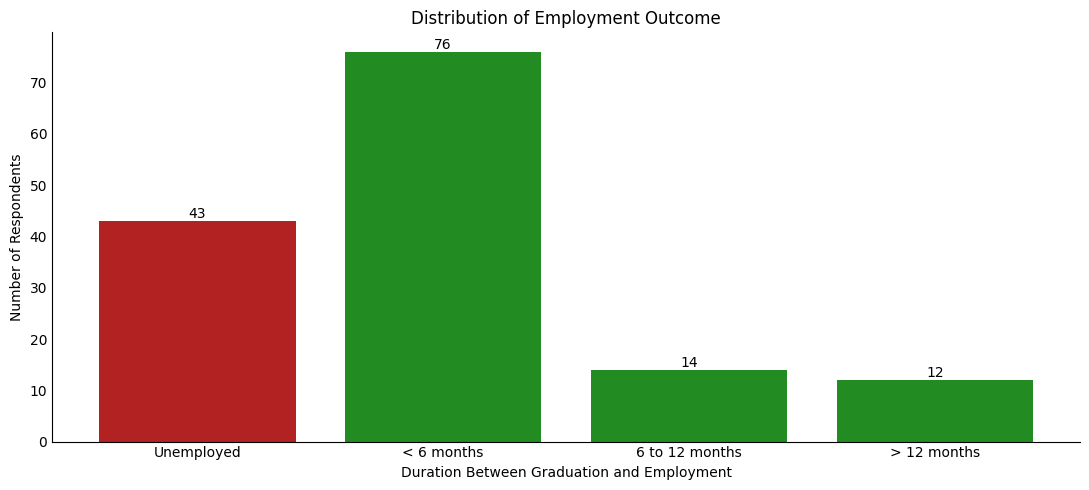

In [ ]:
# 21
# Improved Distribution of Employment Outcome chart

target_order = [
    "No",
    "less than 6 months",
    "6 months to 1 year",
    "more than 1 year"
]

target_labels = [
    "Unemployed",
    "< 6 months",
    "6 to 12 months",
    "> 12 months"
]

target_counts = df_clean["employment_outcome"].value_counts().reindex(target_order)

colors = [
    "firebrick",
    "forestgreen",
    "forestgreen",
    "forestgreen"
]

plt.figure(figsize=(11, 5))

bars = plt.bar(target_labels, target_counts.values, color=colors)

plt.title("Distribution of Employment Outcome")
plt.xlabel("Duration Between Graduation and Employment")
plt.ylabel("Number of Respondents")


ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


ax.tick_params(axis="both", which="both", length=0)


for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        int(height),
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

In [ ]:
#22
target_counts = df_clean["employment_outcome"].value_counts().reindex([
    "No",
    "less than 6 months",
    "6 months to 1 year",
    "more than 1 year"
])

target_percent = (target_counts / target_counts.sum() * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percent": target_percent
})

target_summary

,count,percent
employment_outcome,,
No,43,29.66
less than 6 months,76,52.41
6 months to 1 year,14,9.66
more than 1 year,12,8.28


In [ ]:
#23
# Prepare gender-employment table

gender_col = "A001"

df_clean["gender_clean"] = (
    df_clean[gender_col]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

gender_mapping = {
    "Female": "F",
    "Male": "M",
    "Other": "Other"
}

df_clean["gender_clean"] = df_clean["gender_clean"].map(gender_mapping)

df_gender = df_clean[df_clean["gender_clean"].isin(["F", "M", "Other"])].copy()

target_order = [
    "No",
    "less than 6 months",
    "6 months to 1 year",
    "more than 1 year"
]

target_labels = [
    "Unemployed",
    "< 6 months",
    "6 to 12 months",
    "> 12 months"
]

gender_employment = pd.crosstab(
    df_gender["gender_clean"],
    df_gender["employment_outcome"]
)


gender_employment = gender_employment.reindex(index=["F", "M", "Other"])
gender_employment = gender_employment.reindex(columns=target_order, fill_value=0)


gender_employment.columns = target_labels

gender_employment

,Unemployed,< 6 months,6 to 12 months,> 12 months
gender_clean,,,,
F,24,15,5,2
M,17,59,9,10
Other,0,2,0,0


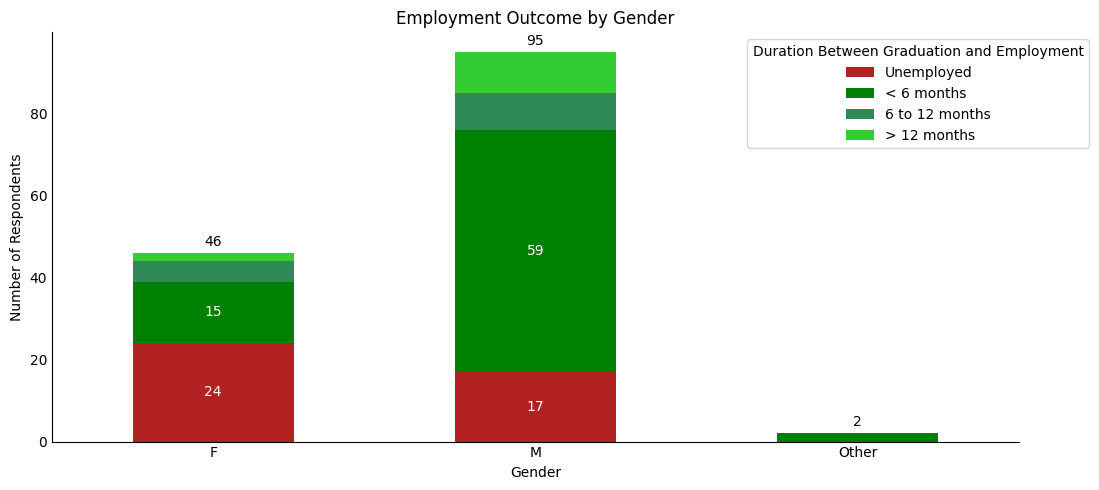

In [ ]:
#24
# Plot count-based stacked bar chart
ax = gender_employment.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 5),
    color=["firebrick", "green", "seagreen", "limegreen"]
)

plt.title("Employment Outcome by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Respondents")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", which="both", length=0)

plt.xticks(rotation=0)

totals = gender_employment.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 1,
        int(total),
        ha="center",
        va="bottom",

    )

for i, gender in enumerate(gender_employment.index):

    # Only label F and M, not Other
    if gender not in ["F", "M"]:
        continue


    top_2_categories = gender_employment.loc[gender].sort_values(ascending=False).head(2).index

    bottom = 0

    for category in gender_employment.columns:
        value = gender_employment.loc[gender, category]

        if category in top_2_categories and value > 0:
            ax.text(
                i,
                bottom + value / 2,
                int(value),
                ha="center",
                va="center",
                color="white",

            )

        bottom += value

plt.legend(
    title="Duration Between Graduation and Employment",
    bbox_to_anchor=(1.08, 1),
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [ ]:
#25
# Employment outcome distribution by asylum-seeker status

asylum_col = "A003"

# Check original values first
df_clean[asylum_col].value_counts(dropna=False)

,count
A003,
No,82
Yes,51
I would rather not disclose,12


In [ ]:
#26
df_clean["asylum_clean"] = (
    df_clean[asylum_col]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

df_clean["asylum_clean"].value_counts(dropna=False)

,count
asylum_clean,
No,82
Yes,51
I would rather not disclose,12


In [ ]:
#27
# Employment outcome distribution by asylum-seeker status

asylum_col = "A003"

df_clean["asylum_clean"] = (
    df_clean[asylum_col]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

# Keep only Yes and No
df_asylum = df_clean[
    df_clean["asylum_clean"].isin(["Yes", "No"])
].copy()

target_order = [
    "No",
    "less than 6 months",
    "6 months to 1 year",
    "more than 1 year"
]

target_labels = [
    "Unemployed",
    "< 6 months",
    "6 to 12 months",
    "> 12 months"
]

asylum_employment = pd.crosstab(
    df_asylum["asylum_clean"],
    df_asylum["employment_outcome"]
)

asylum_employment = asylum_employment.reindex(index=["No", "Yes"])
asylum_employment = asylum_employment.reindex(columns=target_order, fill_value=0)

asylum_employment.columns = target_labels

# Check the table
asylum_employment

,Unemployed,< 6 months,6 to 12 months,> 12 months
asylum_clean,,,,
No,22,44,8,8
Yes,15,26,6,4


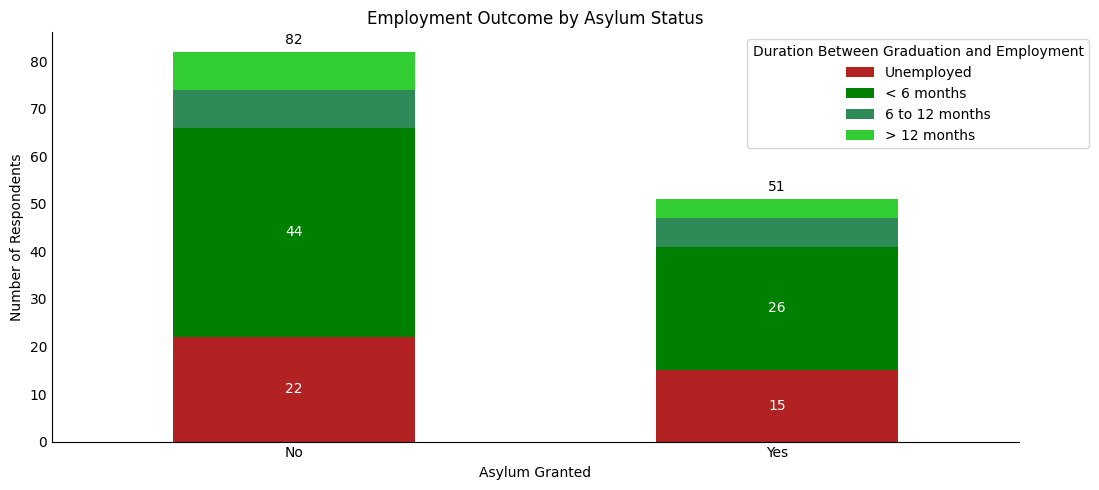

In [ ]:
#28
# Plot count-based stacked bar chart
ax = asylum_employment.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 5),
    color=["firebrick", "green", "seagreen", "limegreen"]
)

plt.title("Employment Outcome by Asylum Status")
plt.xlabel("Asylum Granted")
plt.ylabel("Number of Respondents")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", which="both", length=0)

plt.xticks(rotation=0)

totals = asylum_employment.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 1,
        int(total),
        ha="center",
        va="bottom"
    )

for i, group in enumerate(asylum_employment.index):

    top_2_categories = asylum_employment.loc[group].sort_values(ascending=False).head(2).index

    bottom = 0

    for category in asylum_employment.columns:
        value = asylum_employment.loc[group, category]

        if category in top_2_categories and value > 0:
            ax.text(
                i,
                bottom + value / 2,
                int(value),
                ha="center",
                va="center",
                color="white"
            )

        bottom += value

plt.legend(
    title="Duration Between Graduation and Employment",
    bbox_to_anchor=(1.08, 1),
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [ ]:
# 29
# Employment outcome distribution by institute type

institute_col = "A007"

df_clean["institute_clean"] = (
    df_clean[institute_col]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

df_clean["institute_clean"] = df_clean["institute_clean"].replace({
    "nan": np.nan,
    "": np.nan,
    "None": np.nan
})

df_institute = df_clean[df_clean["institute_clean"].notna()].copy()

target_order = [
    "No",
    "less than 6 months",
    "6 months to 1 year",
    "more than 1 year"
]

target_labels = [
    "Unemployed",
    "< 6 months",
    "6 to 12 months",
    "> 12 months"
]

institute_employment = pd.crosstab(
    df_institute["institute_clean"],
    df_institute["employment_outcome"]
)

institute_employment = institute_employment.reindex(
    index=["Universität", "Hochschule"]
)

institute_employment = institute_employment.reindex(
    columns=target_order,
    fill_value=0
)

institute_employment.columns = target_labels

institute_employment

,Unemployed,< 6 months,6 to 12 months,> 12 months
institute_clean,,,,
Universität,34,57,9,10
Hochschule,9,19,5,2


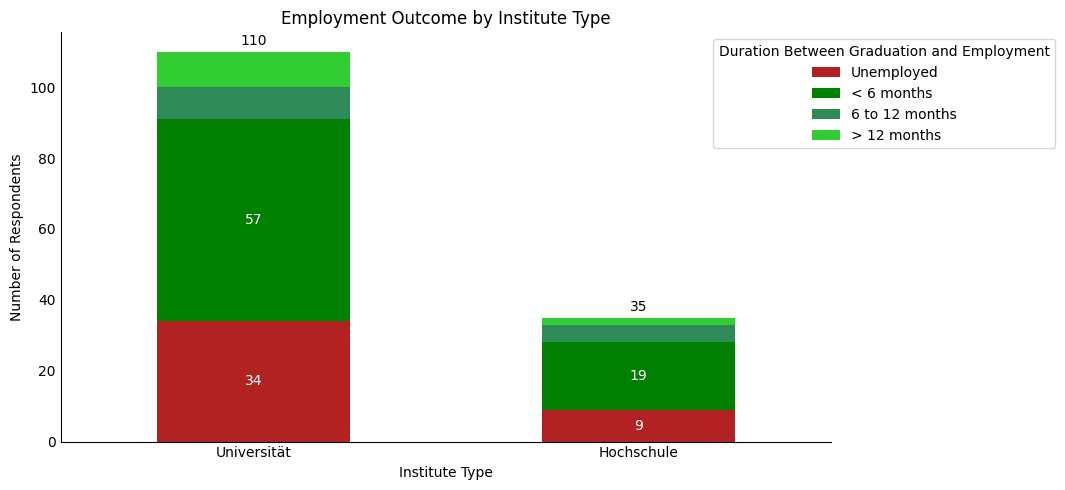

In [ ]:
#30
# Plot count-based stacked bar chart
ax = institute_employment.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 5),
    color=["firebrick", "green", "seagreen", "limegreen"]
)

plt.title("Employment Outcome by Institute Type")
plt.xlabel("Institute Type")
plt.ylabel("Number of Respondents")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="both", which="both", length=0)

plt.xticks(rotation=0)

totals = institute_employment.sum(axis=1)

for i, total in enumerate(totals):
    ax.text(
        i,
        total + 1,
        int(total),
        ha="center",
        va="bottom"
    )

for i, institute in enumerate(institute_employment.index):

    top_2_categories = institute_employment.loc[institute].sort_values(ascending=False).head(2).index

    bottom = 0

    for category in institute_employment.columns:
        value = institute_employment.loc[institute, category]

        if category in top_2_categories and value > 0:
            ax.text(
                i,
                bottom + value / 2,
                int(value),
                ha="center",
                va="center",
                color="white"
            )

        bottom += value

plt.legend(
    title="Duration Between Graduation and Employment",
    bbox_to_anchor=(1.30, 1),
    loc="upper right"
)

plt.tight_layout()
plt.show()

## Model preparation:


In [ ]:
## 31
# Create modelling versions of gender and asylum variables
# "I would rather not disclose" is split approximately half/half

rng = np.random.default_rng(42)

def assign_half_half(index_mask, values):
    """
    Assign values approximately half/half to rows selected by index_mask.
    If the number of rows is odd, one category will receive one extra case.
    """
    n = index_mask.sum()

    assignments = list(values) * (n // len(values))

    if n % len(values) != 0:
        assignments += list(rng.choice(values, size=n % len(values), replace=False))

    assignments = np.array(assignments)
    rng.shuffle(assignments)

    return assignments

In [ ]:
## 32 Gender
# Clean original gender column
gender_raw = (
    df_clean["A001"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

# Create modelling gender column
df_clean["gender_model"] = gender_raw.replace({
    "Female": "F",
    "Male": "M",
    "Other": "Other"
})

# Find respondents who did not disclose gender
gender_not_disclosed = gender_raw.str.lower().str.contains(
    "rather not disclose|not disclose|prefer not",
    na=False
)

# Assign half to F and half to M
df_clean.loc[gender_not_disclosed, "gender_model"] = assign_half_half(
    gender_not_disclosed,
    ["F", "M"]
)

# Check result
df_clean["gender_model"].value_counts(dropna=False)

,count
gender_model,
M,96
F,47
Other,2


In [ ]:
## 33 Asylum
# Clean original asylum column
asylum_raw = (
    df_clean["A003"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

# Create modelling asylum column
df_clean["asylum_model"] = asylum_raw.replace({
    "Yes": "Yes",
    "No": "No"
})

# Find respondents who did not disclose asylum status
asylum_not_disclosed = asylum_raw.str.lower().str.contains(
    "rather not disclose|not disclose|prefer not",
    na=False
)

# Assign half to Yes and half to No
df_clean.loc[asylum_not_disclosed, "asylum_model"] = assign_half_half(
    asylum_not_disclosed,
    ["Yes", "No"]
)

# Check result
df_clean["asylum_model"].value_counts(dropna=False)

,count
asylum_model,
No,88
Yes,57


In [ ]:
#34
# create a copy for the modelling
model_df = df_clean.copy()

print("Initial modelling dataset shape:", model_df.shape)

Initial modelling dataset shape: (145, 36)


In [ ]:
## 35
# excluding people with unrelated jobs
# Clean A018 first
model_df["A018_clean"] = (
    model_df["A018"]
    .astype(str)
    .str.strip()
    .str.replace(".", "", regex=False)
)

# Exclude respondents whose job is not related to their academic field
model_df = model_df[model_df["A018_clean"] != "No"].copy()

print("Shape after excluding unrelated-job cases:", model_df.shape)

Shape after excluding unrelated-job cases: (129, 37)


In [ ]:
#36
leakage_or_unused_cols = [
    "A001",                # original gender, replaced by gender_model
    "gender_clean",        # visualisation version, replaced by gender_model

    "A002",                # arrival year, replaced by years_since_arrival

    "A003",                # original asylum, replaced by asylum_model
    "asylum_clean",        # visualisation version, replaced by asylum_model

    "A007",                # original institute type, replaced by institute_clean
    "A008",                # graduation year

    "A012",                # employment-related / possible leakage
    "A017",                # original employment duration column
    "employment_outcome",  # text target

    "A018",                # whether job is related to field
    "A018_clean",          # cleaned version of A018
    "A019",                # employment-related / possible leakage
    "A021",                # contract type / employment-related

    "A024",                # original volunteer activity column
    "A025",                # original volunteer-related column

    "A015_02",             # free-text / follow-up column, removed for modelling

    "A027",
    "A027_04"
]

model_df = model_df.drop(columns=leakage_or_unused_cols, errors="ignore")

print("Shape after removing leakage/unused columns:", model_df.shape)

Shape after removing leakage/unused columns: (129, 18)


In [ ]:
# 37
# checking numeric variables
numeric_cols = model_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

numeric_cols

['A009', 'employment_class', 'years_since_arrival', 'volunteer_related']

In [ ]:
## 38
# Handle only rule-based missing values before modelling
# Median/mode imputation will be done later inside the modelling pipelines.

# Standardise yes/no-style categorical variables by removing final periods
yes_no_like_cols = ["A010", "A020", "A022", "A023", "A026"]

for col in yes_no_like_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].apply(
            lambda x: str(x).strip().replace(".", "") if pd.notna(x) else np.nan
        )

# Fill columns where blank logically means "No"
blank_means_no_cols = ["A026", "A020", "A022", "A023"]

for col in blank_means_no_cols:
    if col in model_df.columns:
        model_df[col] = model_df[col].fillna("No")

# Make sure GPA is numeric, but do NOT fill missing values here
if "A009" in model_df.columns:
    model_df["A009"] = pd.to_numeric(model_df["A009"], errors="coerce")

# Check remaining missing values before pipeline-based imputation
missing_before_pipeline = pd.DataFrame({
    "missing_count": model_df.isna().sum(),
    "missing_percent": (model_df.isna().mean() * 100).round(2)
}).sort_values(by="missing_percent", ascending=False)

missing_before_pipeline

,missing_count,missing_percent
A015,9,6.98
A013,3,2.33
A014,3,2.33
A004,0,0.00
A006,0,0.00
A009,0,0.00
A011,0,0.00
A010,0,0.00
A020,0,0.00
A022,0,0.00


In [ ]:
# 39
# Spearman correlation with the target variable

correlation_with_target = (
    model_df[numeric_cols]
    .corr(method="spearman")["employment_class"]
    .sort_values(ascending=False)
)

correlation_with_target

,employment_class
employment_class,1.000000
years_since_arrival,0.285476
volunteer_related,0.085700
A009,-0.098512


In [ ]:
#40
# Remove employment_class from the result because it is the target itself

correlation_with_target = correlation_with_target.drop("employment_class")

correlation_with_target

,employment_class
years_since_arrival,0.285476
volunteer_related,0.085700
A009,-0.098512


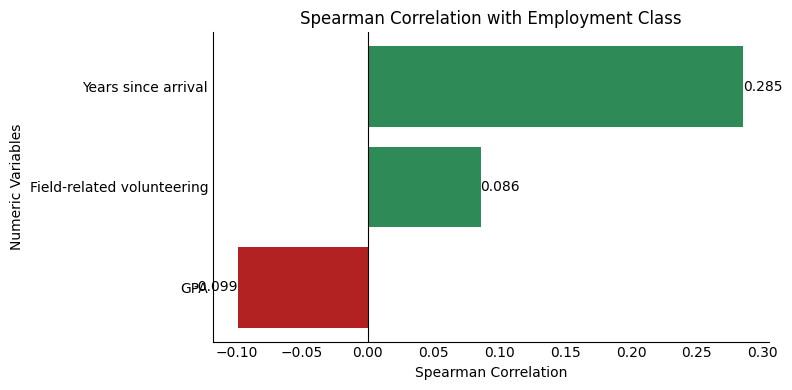

In [ ]:
## 41 Spearman correlation with employment_class visualization


spearman_plot = correlation_with_target.copy()

# Remove target itself if it is still included
spearman_plot = spearman_plot.drop("employment_class", errors="ignore")

# Sort for horizontal bar chart
spearman_plot = spearman_plot.sort_values()

# Optional clearer labels
spearman_labels = {
    "A009": "GPA",
    "years_since_arrival": "Years since arrival",
    "volunteer_related": "Field-related volunteering"
}

spearman_plot.index = spearman_plot.index.map(lambda x: spearman_labels.get(x, x))

# Colors: green for positive, firebrick for negative
colors = ["seagreen" if value >= 0 else "firebrick" for value in spearman_plot.values]

plt.figure(figsize=(8, 4))

bars = plt.barh(
    spearman_plot.index,
    spearman_plot.values,
    color=colors
)

plt.title("Spearman Correlation with Employment Class")
plt.xlabel("Spearman Correlation")
plt.ylabel("Numeric Variables")

# Add vertical line at zero
plt.axvline(0, color="black", linewidth=0.8)

# Remove upper and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Remove ticks
ax.tick_params(axis="both", which="both", length=0)

# Add correlation values beside bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        ha="left" if width >= 0 else "right"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 42 checking categorial variables for cramer v correlation


categorical_cols = model_df.select_dtypes(include=["object", "category"]).columns.tolist()

categorical_cols

['A004',
 'A006',
 'A010',
 'A011',
 'A013',
 'A014',
 'A015',
 'A020',
 'A022',
 'A023',
 'A026',
 'institute_clean',
 'gender_model',
 'asylum_model']

In [ ]:
## 43
# Define and apply Cramér's V for categorical predictors
# For this descriptive association check, missing categorical values are filled
# with the most frequent category, matching the modelling pipeline approach.

def cramers_v(x, y):
    """
    Calculate Cramér's V between two categorical variables.
    Cramér's V ranges from 0 to 1:
    0 = no association
    1 = strong association
    """

    table = pd.crosstab(x, y)

    if table.shape[0] < 2 or table.shape[1] < 2:
        return np.nan

    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()

    r, k = table.shape

    return np.sqrt((chi2 / n) / min(k - 1, r - 1))


categorical_importance = []

for col in categorical_cols:
    temp = model_df[[col, "employment_class"]].copy()

    # Fill missing values with the most frequent category for this check only
    if temp[col].isna().sum() > 0:
        temp[col] = temp[col].fillna(temp[col].mode()[0])

    score = cramers_v(temp[col], temp["employment_class"])

    categorical_importance.append({
        "variable": col,
        "cramers_v": score
    })

categorical_importance = pd.DataFrame(categorical_importance)

categorical_importance = categorical_importance.sort_values(
    by="cramers_v",
    ascending=False
)

categorical_importance

,variable,cramers_v
0,A004,0.367242
8,A022,0.320152
12,gender_model,0.285318
3,A011,0.242880
4,A013,0.221016
2,A010,0.208906
7,A020,0.173525
5,A014,0.147432
11,institute_clean,0.133565
10,A026,0.120812


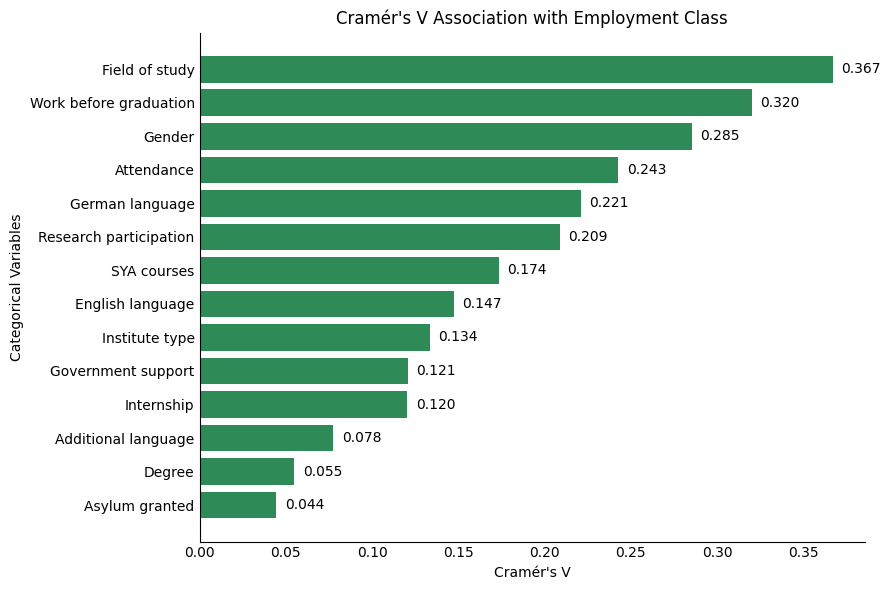

In [ ]:
##44
# Visualize Cramér's V for categorical variables

cramers_plot = categorical_importance.copy()

# Sort values for horizontal bar chart
cramers_plot = cramers_plot.sort_values(by="cramers_v", ascending=True)

# Optional clearer labels
category_labels = {
    "A004": "Field of study",
    "A006": "Degree",
    "A010": "Research participation",
    "A011": "Attendance",
    "A013": "German language",
    "A014": "English language",
    "A015": "Additional language",
    "A020": "SYA courses",
    "A022": "Work before graduation",
    "A023": "Internship",
    "A026": "Government support",
    "institute_clean": "Institute type",
    "gender_model": "Gender",
    "asylum_model": "Asylum granted"
}

cramers_plot["variable_label"] = cramers_plot["variable"].map(
    lambda x: category_labels.get(x, x)
)

plt.figure(figsize=(9, 6))

bars = plt.barh(
    cramers_plot["variable_label"],
    cramers_plot["cramers_v"],
    color="seagreen"
)

plt.title("Cramér's V Association with Employment Class")
plt.xlabel("Cramér's V")
plt.ylabel("Categorical Variables")

# Remove upper and right borders
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Remove ticks
ax.tick_params(axis="both", which="both", length=0)

# Add Cramér's V values beside bars
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 45 checking modelling dataset
print("Final modelling dataset shape:", model_df.shape)

model_df.head()

Final modelling dataset shape: (129, 18)


,A004,A006,A009,A010,A011,A013,A014,A015,A020,A022,A023,A026,employment_class,years_since_arrival,volunteer_related,institute_clean,gender_model,asylum_model
0,"Engineering (Civil, Mechanical...)",Master's,2.4,No,I often attended classes.,C1,B2,No.,No,Yes,No,No,2,9,0,Universität,M,No
1,"Computer & Data Science (AI, IT...)",Master's,2.5,No,I attended nearly half the classes.,C1,B1,Yes: Please Specify:,No,Yes,No,No,4,10,0,Universität,M,Yes
2,"Business & Finance (Management, Marketing, Acc...",Bachelor's,3.0,Yes,I attended most of the classes.,A1,C1,No.,No,No,Yes,No,1,4,0,Universität,M,Yes
3,"Computer & Data Science (AI, IT...)",Master's,1.4,No,I attended most of the classes.,C1,C1,No.,No,Yes,No,No,3,17,0,Universität,F,No
4,"Business & Finance (Management, Marketing, Acc...",Bachelor's,3.6,Yes,I often attended classes.,B2,B2,Yes: Please Specify:,No,Yes,No,Yes,2,11,1,Universität,M,Yes


In [ ]:
## 46 checking columns
model_df.columns.tolist()

['A004',
 'A006',
 'A009',
 'A010',
 'A011',
 'A013',
 'A014',
 'A015',
 'A020',
 'A022',
 'A023',
 'A026',
 'employment_class',
 'years_since_arrival',
 'volunteer_related',
 'institute_clean',
 'gender_model',
 'asylum_model']

In [ ]:
## 47 seperating feautures and target
X = model_df.drop(columns=["employment_class"])
y = model_df["employment_class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (129, 17)
y shape: (129,)


In [ ]:
## 48 showing numeric and categorical feautures
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['A009', 'years_since_arrival', 'volunteer_related']

Categorical features:
['A004', 'A006', 'A010', 'A011', 'A013', 'A014', 'A015', 'A020', 'A022', 'A023', 'A026', 'institute_clean', 'gender_model', 'asylum_model']


In [ ]:
## 49 check for missing values
missing_model = pd.DataFrame({
    "missing_count": X.isna().sum(),
    "missing_percent": (X.isna().mean() * 100).round(2)
}).sort_values(by="missing_percent", ascending=False)

missing_model

,missing_count,missing_percent
A015,9,6.98
A014,3,2.33
A013,3,2.33
A004,0,0.00
A006,0,0.00
A011,0,0.00
A010,0,0.00
A009,0,0.00
A020,0,0.00
A022,0,0.00


## Modelling:

## Method 1:

In [ ]:
## 50
# Prepare target for modelling
# Original employment_class:
# 1 = Unemployed
# 2 = < 6 months
# 3 = 6 to 12 months
# 4 = > 12 months

y_model = y - 1

print("Original target classes:")
print(y.value_counts().sort_index())

print("\nModel target classes:")
print(y_model.value_counts().sort_index())

Original target classes:
employment_class
1    43
2    61
3    14
4    11
Name: count, dtype: int64

Model target classes:
employment_class
0    43
1    61
2    14
3    11
Name: count, dtype: int64


In [ ]:
## 51
# Build preprocessing pipeline

#This prepares the data for all models:
#numeric variables are scaled,
#categorical variables are one-hot encoded.
# Preprocessing for numeric and categorical variables


numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
## 52
## this is to make 5 folds × 5 repeats = 25 model evaluations
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=42
)

In [ ]:
## 53
# defining evaluation metrics
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted"
}

In [ ]:
## 54
# defining the models
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
    n_estimators=300,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42
    ),

}

In [ ]:
## 55
# Method 1 model comparison
method1_results = []

for model_name, model in models.items():

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y_model,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    method1_results.append({
        "method": "Method 1",
        "model": model_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": scores["test_balanced_accuracy"].std(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_std": scores["test_macro_f1"].std(),
        "weighted_f1_mean": scores["test_weighted_f1"].mean(),
        "weighted_f1_std": scores["test_weighted_f1"].std()
    })

method1_results_df = pd.DataFrame(method1_results)

method1_results_df = method1_results_df.sort_values(
    by="macro_f1_mean",
    ascending=False
)

method1_results_df

,method,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
2,Method 1,Random Forest,0.693292,0.089805,0.486987,0.097642,0.489254,0.123661,0.648357,0.098713
3,Method 1,XGBoost,0.645415,0.107655,0.486955,0.119853,0.485986,0.132566,0.613553,0.113166
4,Method 1,Extra Trees,0.670215,0.102287,0.485438,0.118237,0.480017,0.137542,0.630030,0.107396
1,Method 1,Decision Tree,0.556369,0.089478,0.452019,0.119985,0.440630,0.112806,0.547083,0.083611
0,Method 1,Logistic Regression,0.478031,0.069662,0.397703,0.087608,0.372058,0.073003,0.492371,0.076199


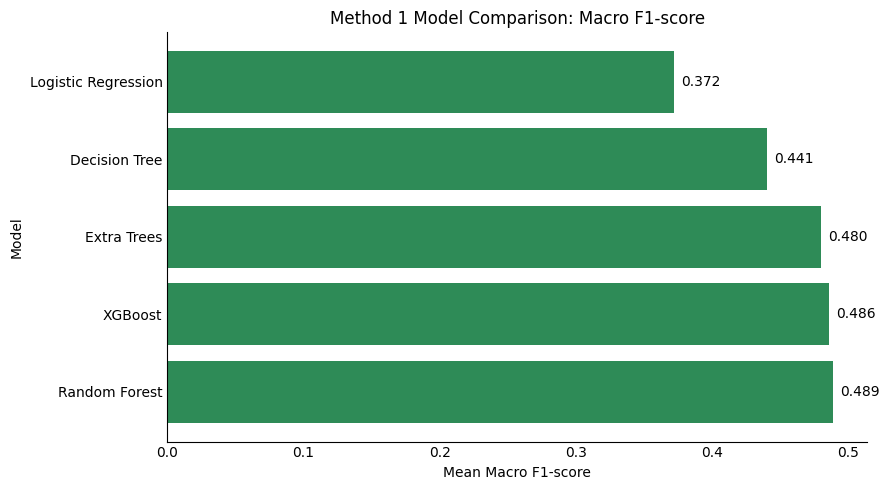

In [ ]:
## 56
# visualization of model comparison
plt.figure(figsize=(9, 5))

bars = plt.barh(
    method1_results_df["model"],
    method1_results_df["macro_f1_mean"],
    color="seagreen"
)

plt.title("Method 1 Model Comparison: Macro F1-score")
plt.xlabel("Mean Macro F1-score")
plt.ylabel("Model")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="both", length=0)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## Method 2:

In [ ]:
## 57
# Defining the models:
models_oversampling = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
    n_estimators=300,
    max_features="sqrt",
    random_state=42
    )
}

In [ ]:
## 58 running and comparing models
method2_results = []

for model_name, model in models_oversampling.items():

    pipeline = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("oversampler", RandomOverSampler(random_state=42)),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y_model,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    method2_results.append({
        "method": "Method 2",
        "model": model_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": scores["test_balanced_accuracy"].std(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_std": scores["test_macro_f1"].std(),
        "weighted_f1_mean": scores["test_weighted_f1"].mean(),
        "weighted_f1_std": scores["test_weighted_f1"].std()
    })

method2_results_df = pd.DataFrame(method2_results)

method2_results_df = method2_results_df.sort_values(
    by="macro_f1_mean",
    ascending=False
)

method2_results_df

,method,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
2,Method 2,Random Forest,0.680923,0.096994,0.527361,0.116011,0.533780,0.130200,0.655555,0.099471
3,Method 2,XGBoost,0.634708,0.122482,0.523996,0.129275,0.515862,0.134798,0.614811,0.121994
4,Method 2,Extra Trees,0.673169,0.088133,0.478291,0.100316,0.471691,0.121535,0.631933,0.094609
1,Method 2,Decision Tree,0.555077,0.082206,0.444594,0.121058,0.426311,0.115157,0.545832,0.079953
0,Method 2,Logistic Regression,0.493538,0.092397,0.420620,0.097472,0.393160,0.082250,0.505632,0.093971


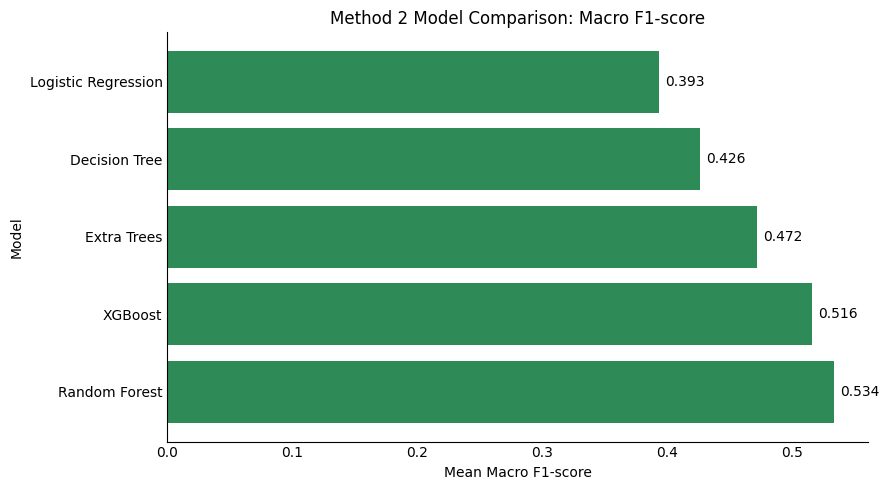

In [ ]:
## 59
# Visualzing mthod 2 models comparison
plt.figure(figsize=(9, 5))

bars = plt.barh(
    method2_results_df["model"],
    method2_results_df["macro_f1_mean"],
    color="seagreen"
)

plt.title("Method 2 Model Comparison: Macro F1-score")
plt.xlabel("Mean Macro F1-score")
plt.ylabel("Model")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="both", length=0)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 60
# Comparing method 1 and method 2
all_results_df = pd.concat(
    [method1_results_df, method2_results_df],
    ignore_index=True
)

all_results_df = all_results_df.sort_values(
    by="macro_f1_mean",
    ascending=False
)

all_results_df

,method,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
5,Method 2,Random Forest,0.680923,0.096994,0.527361,0.116011,0.533780,0.130200,0.655555,0.099471
6,Method 2,XGBoost,0.634708,0.122482,0.523996,0.129275,0.515862,0.134798,0.614811,0.121994
0,Method 1,Random Forest,0.693292,0.089805,0.486987,0.097642,0.489254,0.123661,0.648357,0.098713
1,Method 1,XGBoost,0.645415,0.107655,0.486955,0.119853,0.485986,0.132566,0.613553,0.113166
2,Method 1,Extra Trees,0.670215,0.102287,0.485438,0.118237,0.480017,0.137542,0.630030,0.107396
7,Method 2,Extra Trees,0.673169,0.088133,0.478291,0.100316,0.471691,0.121535,0.631933,0.094609
3,Method 1,Decision Tree,0.556369,0.089478,0.452019,0.119985,0.440630,0.112806,0.547083,0.083611
8,Method 2,Decision Tree,0.555077,0.082206,0.444594,0.121058,0.426311,0.115157,0.545832,0.079953
9,Method 2,Logistic Regression,0.493538,0.092397,0.420620,0.097472,0.393160,0.082250,0.505632,0.093971
4,Method 1,Logistic Regression,0.478031,0.069662,0.397703,0.087608,0.372058,0.073003,0.492371,0.076199


In [ ]:
## 61
# best model
best_by_method = (
    all_results_df
    .sort_values(by="macro_f1_mean", ascending=False)
    .groupby("method")
    .head(1)
)

best_by_method

,method,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
5,Method 2,Random Forest,0.680923,0.096994,0.527361,0.116011,0.533780,0.130200,0.655555,0.099471
0,Method 1,Random Forest,0.693292,0.089805,0.486987,0.097642,0.489254,0.123661,0.648357,0.098713


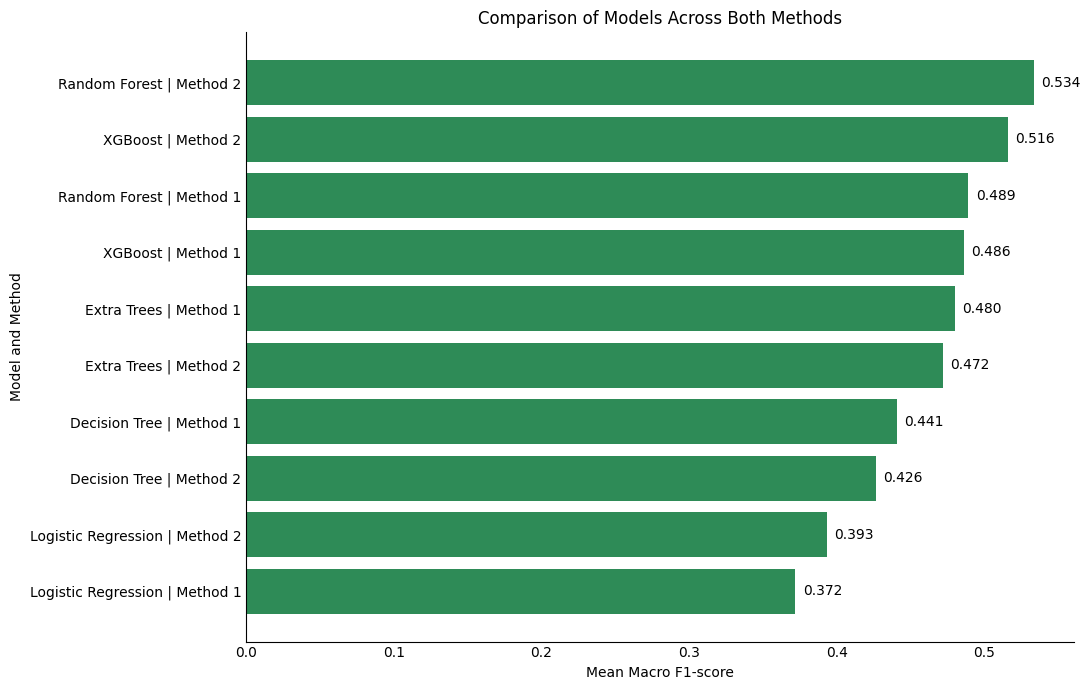

In [ ]:
## 62
# comparing all models
all_results_plot = all_results_df.copy()
all_results_plot["model_method"] = (
    all_results_plot["model"] + " | " + all_results_plot["method"]
)

all_results_plot = all_results_plot.sort_values(
    by="macro_f1_mean",
    ascending=True
)

plt.figure(figsize=(11, 7))

bars = plt.barh(
    all_results_plot["model_method"],
    all_results_plot["macro_f1_mean"],
    color="seagreen"
)

plt.title("Comparison of Models Across Both Methods")
plt.xlabel("Mean Macro F1-score")
plt.ylabel("Model and Method")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="both", length=0)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## Method 3: Synthetic data generation using SMOTENC + repeated stratified cross-validation
#Note: dataset has numeric + categorical variables, we should use SMOTENC, not normal SMOTE. Normal SMOTE is mainly for numeric data and can behave badly with categorical variables.

In [ ]:
## 63
# Prepare preprocessing before SMOTENC
# Number of numeric and categorical features
from sklearn.preprocessing import OrdinalEncoder

# Number of numeric and categorical features
n_numeric = len(numeric_features)
n_categorical = len(categorical_features)

# After preprocessing, numeric columns come first, then categorical columns
categorical_indices = list(range(n_numeric, n_numeric + n_categorical))

# Preprocessing before SMOTENC
# Numeric: median imputation + scaling
# Categorical: most frequent imputation + ordinal encoding
pre_smote_processor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1
            ))
        ]), categorical_features)
    ]
)

categorical_indices

[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]

In [ ]:
## 64 Preprocessing after SMOTENC
# Column indices after pre_smote_processor
numeric_indices_after_smote = list(range(n_numeric))
categorical_indices_after_smote = list(range(n_numeric, n_numeric + n_categorical))

# Preprocessing after SMOTENC
post_smote_processor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_indices_after_smote),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_indices_after_smote)
    ]
)

In [ ]:
## 65
# defining moddels
models_smotenc = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        objective="multi:softprob",
        eval_metric="mlogloss",
        random_state=42
    ),
    "Extra Trees": ExtraTreesClassifier(
    n_estimators=300,
    max_features="sqrt",
    random_state=42
    )
}

In [ ]:
## 66
# modles and comparison
method3_results = []

for model_name, model in models_smotenc.items():

    pipeline = ImbPipeline(steps=[
        ("pre_smote", pre_smote_processor),
        ("smotenc", SMOTENC(
            categorical_features=categorical_indices,
            random_state=42,
            k_neighbors=3
        )),
        ("post_smote", post_smote_processor),
        ("model", model)
    ])

    scores = cross_validate(
        pipeline,
        X,
        y_model,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    method3_results.append({
        "method": "Method3",
        "model": model_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "accuracy_std": scores["test_accuracy"].std(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "balanced_accuracy_std": scores["test_balanced_accuracy"].std(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_std": scores["test_macro_f1"].std(),
        "weighted_f1_mean": scores["test_weighted_f1"].mean(),
        "weighted_f1_std": scores["test_weighted_f1"].std()
    })

method3_results_df = pd.DataFrame(method3_results)

method3_results_df = method3_results_df.sort_values(
    by="macro_f1_mean",
    ascending=False
)

method3_results_df

,method,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
4,Method3,Extra Trees,0.656431,0.097033,0.513440,0.117022,0.506194,0.130632,0.637542,0.098608
2,Method3,Random Forest,0.659446,0.097729,0.495064,0.105853,0.484037,0.109003,0.629524,0.098033
3,Method3,XGBoost,0.608062,0.077245,0.476303,0.105680,0.463334,0.101965,0.585955,0.081956
1,Method3,Decision Tree,0.574215,0.112335,0.446303,0.116746,0.422979,0.111269,0.565263,0.111975
0,Method3,Logistic Regression,0.529046,0.093533,0.398387,0.102548,0.383785,0.093246,0.519073,0.095498


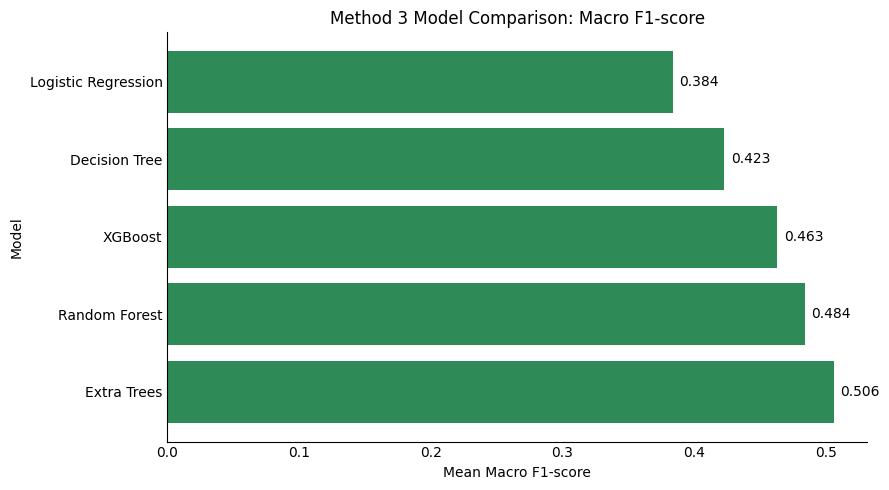

In [ ]:
## 67
# comparison visualization
plt.figure(figsize=(9, 5))

bars = plt.barh(
    method3_results_df["model"],
    method3_results_df["macro_f1_mean"],
    color="seagreen"
)

plt.title("Method 3 Model Comparison: Macro F1-score")
plt.xlabel("Mean Macro F1-score")
plt.ylabel("Model")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="both", length=0)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 68
# comparing all 3 methods
all_results_df = pd.concat(
    [method1_results_df, method2_results_df, method3_results_df],
    ignore_index=True
)

all_results_df = all_results_df.sort_values(
    by="macro_f1_mean",
    ascending=False
)

all_results_df

,method,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
5,Method 2,Random Forest,0.680923,0.096994,0.527361,0.116011,0.533780,0.130200,0.655555,0.099471
6,Method 2,XGBoost,0.634708,0.122482,0.523996,0.129275,0.515862,0.134798,0.614811,0.121994
10,SMOTENC synthetic generation + repeated strati...,Extra Trees,0.656431,0.097033,0.513440,0.117022,0.506194,0.130632,0.637542,0.098608
0,Method 1,Random Forest,0.693292,0.089805,0.486987,0.097642,0.489254,0.123661,0.648357,0.098713
1,Method 1,XGBoost,0.645415,0.107655,0.486955,0.119853,0.485986,0.132566,0.613553,0.113166
11,SMOTENC synthetic generation + repeated strati...,Random Forest,0.659446,0.097729,0.495064,0.105853,0.484037,0.109003,0.629524,0.098033
2,Method 1,Extra Trees,0.670215,0.102287,0.485438,0.118237,0.480017,0.137542,0.630030,0.107396
7,Method 2,Extra Trees,0.673169,0.088133,0.478291,0.100316,0.471691,0.121535,0.631933,0.094609
12,SMOTENC synthetic generation + repeated strati...,XGBoost,0.608062,0.077245,0.476303,0.105680,0.463334,0.101965,0.585955,0.081956
3,Method 1,Decision Tree,0.556369,0.089478,0.452019,0.119985,0.440630,0.112806,0.547083,0.083611


In [ ]:
## 69
# best model from each
best_by_method = (
    all_results_df
    .sort_values(by="macro_f1_mean", ascending=False)
    .groupby("method")
    .head(1)
)

best_by_method

,method,model,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
5,Method 2,Random Forest,0.680923,0.096994,0.527361,0.116011,0.533780,0.130200,0.655555,0.099471
10,SMOTENC synthetic generation + repeated strati...,Extra Trees,0.656431,0.097033,0.513440,0.117022,0.506194,0.130632,0.637542,0.098608
0,Method 1,Random Forest,0.693292,0.089805,0.486987,0.097642,0.489254,0.123661,0.648357,0.098713


## Best models fine tuning:

## This section fine-tunes the strongest models from the previous comparison. Since random oversampling produced the best overall results, the fine-tuning stage focuses on models combined with random oversampling and repeated stratified cross-validation. The models are tested using both the full feature set and a reduced feature set based on the exploratory association analysis.

In [ ]:
## 70
# Combine numeric Spearman and categorical Cramér's V results

numeric_importance = (
    correlation_with_target
    .drop("employment_class", errors="ignore")
    .abs()
    .reset_index()
)

numeric_importance.columns = ["variable", "association_score"]
numeric_importance["association_type"] = "Spearman"

categorical_importance_for_selection = categorical_importance.copy()
categorical_importance_for_selection = categorical_importance_for_selection.rename(
    columns={"cramers_v": "association_score"}
)
categorical_importance_for_selection["association_type"] = "Cramer's V"

feature_association = pd.concat(
    [numeric_importance, categorical_importance_for_selection],
    ignore_index=True
)

feature_association = feature_association.sort_values(
    by="association_score",
    ascending=False
)

feature_association

,variable,association_score,association_type
3,A004,0.367242,Cramer's V
4,A022,0.320152,Cramer's V
0,years_since_arrival,0.285476,Spearman
5,gender_model,0.285318,Cramer's V
6,A011,0.242880,Cramer's V
7,A013,0.221016,Cramer's V
8,A010,0.208906,Cramer's V
9,A020,0.173525,Cramer's V
10,A014,0.147432,Cramer's V
11,institute_clean,0.133565,Cramer's V


In [ ]:
## 71
# Create reduced feature set based on exploratory association scores

association_threshold = 0.10

selected_features = feature_association[
    feature_association["association_score"] >= association_threshold
]["variable"].tolist()

# Force-keep theoretically important academic variables
force_keep_features = [
    "A004",  # Field of study
    "A006",  # Degree
    "A009",  # GPA
    "A015"   # Additional language
]

for col in force_keep_features:
    if col in X.columns and col not in selected_features:
        selected_features.append(col)

# Keep only columns that actually exist in X
selected_features = [col for col in selected_features if col in X.columns]

removed_features = [col for col in X.columns if col not in selected_features]

print("Selected features:")
print(selected_features)

print("\nRemoved features:")
print(removed_features)

print("\nNumber of original features:", X.shape[1])
print("Number of selected features:", len(selected_features))

Selected features:
['A004', 'A022', 'years_since_arrival', 'gender_model', 'A011', 'A013', 'A010', 'A020', 'A014', 'institute_clean', 'A026', 'A023', 'A006', 'A009', 'A015']

Removed features:
['volunteer_related', 'asylum_model']

Number of original features: 17
Number of selected features: 15


In [ ]:
## 72
# Create full and reduced feature datasets

X_all = X.copy()
X_reduced = X[selected_features].copy()

print("Full feature set shape:", X_all.shape)
print("Reduced feature set shape:", X_reduced.shape)

Full feature set shape: (129, 17)
Reduced feature set shape: (129, 15)


In [ ]:
## 73
#  defining unction to build preprocessing pipeline for any feature set

def build_preprocessor(X_data):
    """
    Build preprocessing pipeline for a given feature set.
    Numeric variables: median imputation + scaling.
    Categorical variables: most frequent imputation + one-hot encoding.
    """

    numeric_cols = X_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
    categorical_cols = X_data.select_dtypes(include=["object", "category"]).columns.tolist()

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    return preprocessor

In [ ]:
## 75
# defining the function for fine-tuning models with random oversampling

def tune_model(model_name, model, param_distributions, X_data, y_data, n_iter=10):
    """
    Tune one model using random oversampling and repeated stratified CV.
    Main scoring metric: macro F1-score.
    """

    current_preprocessor = build_preprocessor(X_data)

    pipeline = ImbPipeline(steps=[
        ("preprocessor", current_preprocessor),
        ("oversampler", RandomOverSampler(random_state=42)),
        ("model", model)
    ])

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_distributions,
        n_iter=n_iter,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        random_state=42,
        verbose=1
    )

    search.fit(X_data, y_data)

    return {
        "model": model_name,
        "best_macro_f1": search.best_score_,
        "best_params": search.best_params_,
        "best_estimator": search.best_estimator_
    }

In [ ]:
## 76
# Fine-tune Random Forest

rf_param_dist = {
    "model__n_estimators": randint(200, 800),
    "model__max_depth": [None, 3, 5, 7, 10, 15],
    "model__min_samples_split": randint(2, 15),
    "model__min_samples_leaf": randint(1, 8),
    "model__max_features": ["sqrt", "log2", None]
}

rf_model = RandomForestClassifier(
    random_state=42
)

rf_tuned_full = tune_model(
    model_name="Random Forest - full features",
    model=rf_model,
    param_distributions=rf_param_dist,
    X_data=X_all,
    y_data=y_model,
    n_iter=10
)

rf_tuned_reduced = tune_model(
    model_name="Random Forest - reduced features",
    model=rf_model,
    param_distributions=rf_param_dist,
    X_data=X_reduced,
    y_data=y_model,
    n_iter=10
)

Fitting 25 folds for each of 10 candidates, totalling 250 fits
Fitting 25 folds for each of 10 candidates, totalling 250 fits


In [ ]:
## 77
# Fine-tune Extra Trees

et_param_dist = {
    "model__n_estimators": randint(200, 800),
    "model__max_depth": [None, 3, 5, 7, 10, 15],
    "model__min_samples_split": randint(2, 15),
    "model__min_samples_leaf": randint(1, 8),
    "model__max_features": ["sqrt", "log2", None]
}

et_model = ExtraTreesClassifier(
    random_state=42
)

et_tuned_full = tune_model(
    model_name="Extra Trees - full features",
    model=et_model,
    param_distributions=et_param_dist,
    X_data=X_all,
    y_data=y_model,
    n_iter=10
)

et_tuned_reduced = tune_model(
    model_name="Extra Trees - reduced features",
    model=et_model,
    param_distributions=et_param_dist,
    X_data=X_reduced,
    y_data=y_model,
    n_iter=10
)

Fitting 25 folds for each of 10 candidates, totalling 250 fits
Fitting 25 folds for each of 10 candidates, totalling 250 fits


In [ ]:
## 78
# Fine-tune XGBoost

xgb_param_dist = {
    "model__n_estimators": randint(100, 600),
    "model__learning_rate": uniform(0.01, 0.15),
    "model__max_depth": randint(2, 7),
    "model__min_child_weight": randint(1, 8),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__reg_lambda": uniform(0.5, 5.0)
}

xgb_model = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=1
)

xgb_tuned_full = tune_model(
    model_name="XGBoost - full features",
    model=xgb_model,
    param_distributions=xgb_param_dist,
    X_data=X_all,
    y_data=y_model,
    n_iter=10
)

xgb_tuned_reduced = tune_model(
    model_name="XGBoost - reduced features",
    model=xgb_model,
    param_distributions=xgb_param_dist,
    X_data=X_reduced,
    y_data=y_model,
    n_iter=10
)

Fitting 25 folds for each of 10 candidates, totalling 250 fits
Fitting 25 folds for each of 10 candidates, totalling 250 fits


In [ ]:
## 79
# Compare tuned models

tuned_results = [
    rf_tuned_full,
    rf_tuned_reduced,
    et_tuned_full,
    et_tuned_reduced,
    xgb_tuned_full,
    xgb_tuned_reduced
]

tuned_results_df = pd.DataFrame([
    {
        "model": result["model"],
        "best_macro_f1": result["best_macro_f1"],
        "best_params": result["best_params"]
    }
    for result in tuned_results
])

tuned_results_df = tuned_results_df.sort_values(
    by="best_macro_f1",
    ascending=False
)

tuned_results_df

,model,best_macro_f1,best_params
5,XGBoost - reduced features,0.531651,{'model__colsample_bytree': 0.9233589392465844...
1,Random Forest - reduced features,0.522689,"{'model__max_depth': None, 'model__max_feature..."
4,XGBoost - full features,0.522351,{'model__colsample_bytree': 0.9233589392465844...
0,Random Forest - full features,0.512470,"{'model__max_depth': None, 'model__max_feature..."
3,Extra Trees - reduced features,0.467649,"{'model__max_depth': 15, 'model__max_features'..."
2,Extra Trees - full features,0.462937,"{'model__max_depth': 15, 'model__max_features'..."


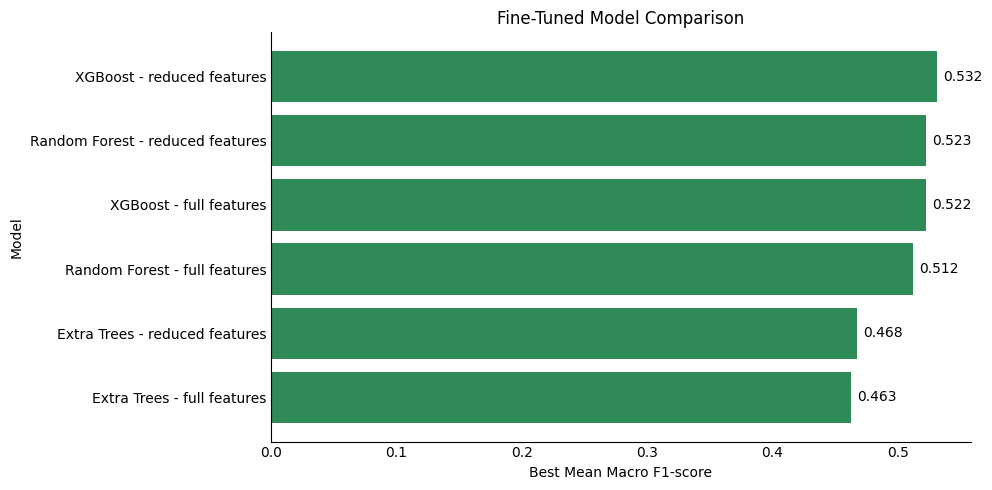

In [ ]:
## 80
# Visualise tuned model comparison

plot_df = tuned_results_df.sort_values(
    by="best_macro_f1",
    ascending=True
)

plt.figure(figsize=(10, 5))

bars = plt.barh(
    plot_df["model"],
    plot_df["best_macro_f1"],
    color="seagreen"
)

plt.title("Fine-Tuned Model Comparison")
plt.xlabel("Best Mean Macro F1-score")
plt.ylabel("Model")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="both", which="both", length=0)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
## 81
print("Best model:")
print(tuned_results_df.iloc[0]["model"])

print("\nBest macro F1:")
print(tuned_results_df.iloc[0]["best_macro_f1"])

print("\nBest parameters:")
tuned_results_df.iloc[0]["best_params"]

Best model:
XGBoost - reduced features

Best macro F1:
0.531650529582446

Best parameters:


{'model__colsample_bytree': np.float64(0.9233589392465844),
 'model__learning_rate': np.float64(0.0556920653760056),
 'model__max_depth': 6,
 'model__min_child_weight': 2,
 'model__n_estimators': 439,
 'model__reg_lambda': np.float64(1.7051273301300585),
 'model__subsample': np.float64(0.8733054075301833)}

In [ ]:
## 82
print("Selected features:")
print(selected_features)

print("\nRemoved features:")
print(removed_features)

Selected features:
['A004', 'A022', 'years_since_arrival', 'gender_model', 'A011', 'A013', 'A010', 'A020', 'A014', 'institute_clean', 'A026', 'A023', 'A006', 'A009', 'A015']

Removed features:
['volunteer_related', 'asylum_model']


In [ ]:
## 83
xgb_tuned_reduced_final = tune_model(
    model_name="XGBoost - reduced features - final tuning",
    model=xgb_model,
    param_distributions=xgb_param_dist,
    X_data=X_reduced,
    y_data=y_model,
    n_iter=50
)

xgb_tuned_reduced_final

Fitting 25 folds for each of 50 candidates, totalling 1250 fits


{'model': 'XGBoost - reduced features - final tuning',
 'best_macro_f1': np.float64(0.5566331291035915),
 'best_params': {'model__colsample_bytree': np.float64(0.9906459823330611),
  'model__learning_rate': np.float64(0.07165555199773468),
  'model__max_depth': 6,
  'model__min_child_weight': 1,
  'model__n_estimators': 484,
  'model__reg_lambda': np.float64(1.697809453334862),
  'model__subsample': np.float64(0.6579579488364892)},
 'best_estimator': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['years_since_arrival',
                              

In [ ]:
## 84
final_tuning_comparison = pd.DataFrame([
    {
        "model": "XGBoost - reduced features - first tuning",
        "macro_f1": xgb_tuned_reduced["best_macro_f1"],
        "best_params": xgb_tuned_reduced["best_params"]
    },
    {
        "model": "XGBoost - reduced features - final tuning",
        "macro_f1": xgb_tuned_reduced_final["best_macro_f1"],
        "best_params": xgb_tuned_reduced_final["best_params"]
    }
])

final_tuning_comparison.sort_values(by="macro_f1", ascending=False)

,model,macro_f1,best_params
1,XGBoost - reduced features - final tuning,0.556633,{'model__colsample_bytree': 0.9906459823330611...
0,XGBoost - reduced features - first tuning,0.531651,{'model__colsample_bytree': 0.9233589392465844...


In [ ]:
## 85
print("Best final tuned model:")
print(xgb_tuned_reduced_final["model"])

print("\nBest macro F1:")
print(xgb_tuned_reduced_final["best_macro_f1"])

print("\nBest parameters:")
xgb_tuned_reduced_final["best_params"]

Best final tuned model:
XGBoost - reduced features - final tuning

Best macro F1:
0.5566331291035915

Best parameters:


{'model__colsample_bytree': np.float64(0.9906459823330611),
 'model__learning_rate': np.float64(0.07165555199773468),
 'model__max_depth': 6,
 'model__min_child_weight': 1,
 'model__n_estimators': 484,
 'model__reg_lambda': np.float64(1.697809453334862),
 'model__subsample': np.float64(0.6579579488364892)}

In [ ]:
## 86


# Use the final tuned model
final_model = xgb_tuned_reduced_final["best_estimator"]

# cross_val_predict requires non-repeated folds
cv_predict = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Generate out-of-fold predictions
y_pred_cv = cross_val_predict(
    final_model,
    X_reduced,
    y_model,
    cv=cv_predict,
    n_jobs=-1
)

In [ ]:
## 87
target_names = [
    "Unemployed",
    "< 6 months",
    "6 to 12 months",
    "> 12 months"
]

print(classification_report(
    y_model,
    y_pred_cv,
    target_names=target_names
))

                precision    recall  f1-score   support

    Unemployed       0.70      0.81      0.75        43
    < 6 months       0.74      0.74      0.74        61
6 to 12 months       0.55      0.43      0.48        14
   > 12 months       0.71      0.45      0.56        11

      accuracy                           0.71       129
     macro avg       0.67      0.61      0.63       129
  weighted avg       0.70      0.71      0.70       129



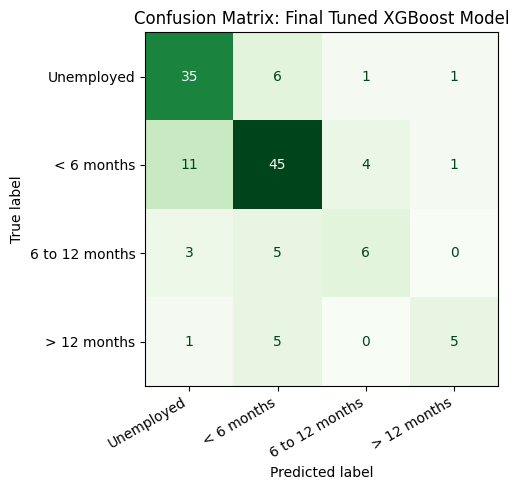

In [ ]:
## 88
cm = confusion_matrix(y_model, y_pred_cv)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_names
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap="Greens", colorbar=False)

plt.title("Confusion Matrix: Final Tuned XGBoost Model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Alternative 3 class target approach

In [ ]:
## 89
# Create alternative 3-class target
# Original:
# 1 = Unemployed
# 2 = < 6 months
# 3 = 6 to 12 months
# 4 = > 12 months
#
# New:
# 1 = Unemployed
# 2 = < 6 months
# 3 = > 6 months

model_df_3 = model_df.copy()

model_df_3["employment_class_3"] = model_df_3["employment_class"].replace({
    1: 1,
    2: 2,
    3: 3,
    4: 3
})

print("3-class target distribution:")
print(model_df_3["employment_class_3"].value_counts().sort_index())

3-class target distribution:
employment_class_3
1    43
2    61
3    25
Name: count, dtype: int64


In [ ]:
## 90
# Separate predictors and 3-class target

X_3 = model_df_3.drop(columns=["employment_class", "employment_class_3"])
y_3 = model_df_3["employment_class_3"]

# Convert 1,2,3 to 0,1,2 for XGBoost
y_3_model = y_3 - 1

print("X_3 shape:", X_3.shape)
print("y_3 shape:", y_3_model.shape)

print("\nModel target distribution:")
print(y_3_model.value_counts().sort_index())

X_3 shape: (129, 17)
y_3 shape: (129,)

Model target distribution:
employment_class_3
0    43
1    61
2    25
Name: count, dtype: int64


In [ ]:
## 91
# Recalculate feature types
numeric_features_3 = X_3.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features_3 = X_3.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric features:")
print(numeric_features_3)

print("\nCategorical features:")
print(categorical_features_3)

Numeric features:
['A009', 'years_since_arrival', 'volunteer_related']

Categorical features:
['A004', 'A006', 'A010', 'A011', 'A013', 'A014', 'A015', 'A020', 'A022', 'A023', 'A026', 'institute_clean', 'gender_model', 'asylum_model']


In [ ]:
## 92
# Spearman correlation with 3-class target

spearman_data_3 = pd.concat(
    [X_3[numeric_features_3], y_3.rename("employment_class_3")],
    axis=1
)

correlation_with_target_3 = (
    spearman_data_3
    .corr(method="spearman")["employment_class_3"]
    .drop("employment_class_3")
    .sort_values(ascending=False)
)

correlation_with_target_3

,employment_class_3
years_since_arrival,0.288861
volunteer_related,0.080148
A009,-0.111033


In [ ]:
## 93
# Cramér's V with 3-class target

categorical_importance_3 = []

for col in categorical_features_3:
    temp = pd.DataFrame({
        col: X_3[col],
        "employment_class_3": y_3
    })

    # Fill missing values with the most frequent category for this descriptive check only
    if temp[col].isna().sum() > 0:
        temp[col] = temp[col].fillna(temp[col].mode()[0])

    score = cramers_v(temp[col], temp["employment_class_3"])

    categorical_importance_3.append({
        "variable": col,
        "cramers_v": score
    })

categorical_importance_3 = pd.DataFrame(categorical_importance_3)

categorical_importance_3 = categorical_importance_3.sort_values(
    by="cramers_v",
    ascending=False
)

categorical_importance_3

,variable,cramers_v
0,A004,0.375604
8,A022,0.319993
12,gender_model,0.279423
3,A011,0.272005
4,A013,0.232301
7,A020,0.171055
5,A014,0.145852
2,A010,0.127576
10,A026,0.115545
11,institute_clean,0.102055


In [ ]:
## 94
# Combine numeric Spearman and categorical Cramér's V results for 3-class target

numeric_importance_3 = (
    correlation_with_target_3
    .abs()
    .reset_index()
)

numeric_importance_3.columns = ["variable", "association_score"]
numeric_importance_3["association_type"] = "Spearman"

categorical_importance_for_selection_3 = categorical_importance_3.copy()
categorical_importance_for_selection_3 = categorical_importance_for_selection_3.rename(
    columns={"cramers_v": "association_score"}
)
categorical_importance_for_selection_3["association_type"] = "Cramer's V"

feature_association_3 = pd.concat(
    [numeric_importance_3, categorical_importance_for_selection_3],
    ignore_index=True
)

feature_association_3 = feature_association_3.sort_values(
    by="association_score",
    ascending=False
)

feature_association_3

,variable,association_score,association_type
3,A004,0.375604,Cramer's V
4,A022,0.319993,Cramer's V
0,years_since_arrival,0.288861,Spearman
5,gender_model,0.279423,Cramer's V
6,A011,0.272005,Cramer's V
7,A013,0.232301,Cramer's V
8,A020,0.171055,Cramer's V
9,A014,0.145852,Cramer's V
10,A010,0.127576,Cramer's V
11,A026,0.115545,Cramer's V


In [ ]:
## 95
# Create reduced feature set for 3-class model

association_threshold = 0.10

selected_features_3 = feature_association_3[
    feature_association_3["association_score"] >= association_threshold
]["variable"].tolist()

# Force-keep theoretically important academic variables
force_keep_features = [
    "A004",  # Field of study
    "A006",  # Degree
    "A009",  # GPA
    "A015"   # Additional language
]

for col in force_keep_features:
    if col in X_3.columns and col not in selected_features_3:
        selected_features_3.append(col)

selected_features_3 = [col for col in selected_features_3 if col in X_3.columns]

removed_features_3 = [col for col in X_3.columns if col not in selected_features_3]

X_3_reduced = X_3[selected_features_3].copy()

print("Selected features for 3-class model:")
print(selected_features_3)

print("\nRemoved features for 3-class model:")
print(removed_features_3)

print("\nFull feature set shape:", X_3.shape)
print("Reduced feature set shape:", X_3_reduced.shape)

Selected features for 3-class model:
['A004', 'A022', 'years_since_arrival', 'gender_model', 'A011', 'A013', 'A020', 'A014', 'A010', 'A026', 'A009', 'institute_clean', 'A006', 'A015']

Removed features for 3-class model:
['A023', 'volunteer_related', 'asylum_model']

Full feature set shape: (129, 17)
Reduced feature set shape: (129, 14)


In [ ]:
## 96
# Fine-tune XGBoost for 3-class target using reduced features

xgb_3class_tuned = tune_model(
    model_name="XGBoost - 3-class target - reduced features",
    model=xgb_model,
    param_distributions=xgb_param_dist,
    X_data=X_3_reduced,
    y_data=y_3_model,
    n_iter=50
)

xgb_3class_tuned

Fitting 25 folds for each of 50 candidates, totalling 1250 fits


{'model': 'XGBoost - 3-class target - reduced features',
 'best_macro_f1': np.float64(0.6373445992597676),
 'best_params': {'model__colsample_bytree': np.float64(0.7793696571944989),
  'model__learning_rate': np.float64(0.1591686193916231),
  'model__max_depth': 5,
  'model__min_child_weight': 1,
  'model__n_estimators': 167,
  'model__reg_lambda': np.float64(1.6862454374840004),
  'model__subsample': np.float64(0.7301598792637071)},
 'best_estimator': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['years_since_arrival',
                            

In [ ]:
## 97
target_comparison = pd.DataFrame([
    {
        "target_structure": "4-class target",
        "model": "XGBoost - reduced features",
        "macro_f1": xgb_tuned_reduced_final["best_macro_f1"]
    },
    {
        "target_structure": "3-class target",
        "model": "XGBoost - reduced features",
        "macro_f1": xgb_3class_tuned["best_macro_f1"]
    }
])

target_comparison.sort_values(by="macro_f1", ascending=False)

,target_structure,model,macro_f1
1,3-class target,XGBoost - reduced features,0.637345
0,4-class target,XGBoost - reduced features,0.556633


In [ ]:
## 98

final_model_3 = xgb_3class_tuned["best_estimator"]

cv_predict_3 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_3_pred_cv = cross_val_predict(
    final_model_3,
    X_3_reduced,
    y_3_model,
    cv=cv_predict_3,
    n_jobs=-1
)

target_names_3 = [
    "Unemployed",
    "< 6 months",
    "> 6 months"
]

print(classification_report(
    y_3_model,
    y_3_pred_cv,
    target_names=target_names_3
))

              precision    recall  f1-score   support

  Unemployed       0.68      0.74      0.71        43
  < 6 months       0.72      0.77      0.75        61
  > 6 months       0.59      0.40      0.48        25

    accuracy                           0.69       129
   macro avg       0.66      0.64      0.64       129
weighted avg       0.68      0.69      0.68       129



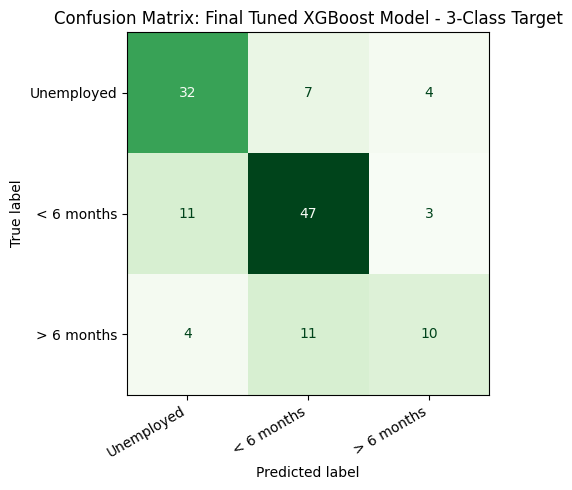

In [ ]:
## 99
cm_3 = confusion_matrix(y_3_model, y_3_pred_cv)

disp_3 = ConfusionMatrixDisplay(
    confusion_matrix=cm_3,
    display_labels=target_names_3
)

fig, ax = plt.subplots(figsize=(7, 5))
disp_3.plot(ax=ax, cmap="Greens", colorbar=False)

plt.title("Confusion Matrix: Final Tuned XGBoost Model - 3-Class Target")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
## 100
# Fine-tune Random Forest for 3-class target using reduced features

rf_3class_tuned = tune_model(
    model_name="Random Forest - 3-class target - reduced features",
    model=RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    X_data=X_3_reduced,
    y_data=y_3_model,
    n_iter=50
)

rf_3class_tuned

Fitting 25 folds for each of 50 candidates, totalling 1250 fits


{'model': 'Random Forest - 3-class target - reduced features',
 'best_macro_f1': np.float64(0.598722539591672),
 'best_params': {'model__max_depth': 10,
  'model__max_features': 'sqrt',
  'model__min_samples_leaf': 1,
  'model__min_samples_split': 8,
  'model__n_estimators': 720},
 'best_estimator': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['years_since_arrival',
                                                    'A009']),
                                                  ('cat',
                                                   Pipeline(step

In [ ]:
## 101
three_class_tuned_comparison = pd.DataFrame([
    {
        "model": "XGBoost - 3-class reduced",
        "macro_f1": xgb_3class_tuned["best_macro_f1"],
        "best_params": xgb_3class_tuned["best_params"]
    },
    {
        "model": "Random Forest - 3-class reduced",
        "macro_f1": rf_3class_tuned["best_macro_f1"],
        "best_params": rf_3class_tuned["best_params"]
    }
])

three_class_tuned_comparison.sort_values(by="macro_f1", ascending=False)

,model,macro_f1,best_params
0,XGBoost - 3-class reduced,0.637345,{'model__colsample_bytree': 0.7793696571944989...
1,Random Forest - 3-class reduced,0.598723,"{'model__max_depth': 10, 'model__max_features'..."


In [ ]:
## 102
# here I also tried Catboost
catboost_param_dist = {
    "model__iterations": randint(100, 600),
    "model__depth": randint(2, 8),
    "model__learning_rate": uniform(0.01, 0.15),
    "model__l2_leaf_reg": uniform(1, 10)
}

catboost_model = CatBoostClassifier(
    loss_function="MultiClass",
    verbose=0,
    random_state=42
)

catboost_3class_tuned = tune_model(
    model_name="CatBoost - 3-class target - reduced features",
    model=catboost_model,
    param_distributions=catboost_param_dist,
    X_data=X_3_reduced,
    y_data=y_3_model,
    n_iter=50
)

catboost_3class_tuned

Fitting 25 folds for each of 50 candidates, totalling 1250 fits


{'model': 'CatBoost - 3-class target - reduced features',
 'best_macro_f1': np.float64(0.6601501434056231),
 'best_params': {'model__depth': 5,
  'model__iterations': 448,
  'model__l2_leaf_reg': np.float64(2.8343478986616377),
  'model__learning_rate': np.float64(0.12695365004091538)},
 'best_estimator': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['years_since_arrival',
                                                    'A009']),
                                                  ('cat',
                                                   Pipelin

In [ ]:
## 103
# I need to make a comparison now.
three_class_tuned_comparison = pd.DataFrame([
    {
        "model": "XGBoost - 3-class reduced",
        "macro_f1": xgb_3class_tuned["best_macro_f1"],
        "best_params": xgb_3class_tuned["best_params"]
    },
    {
        "model": "Random Forest - 3-class reduced",
        "macro_f1": rf_3class_tuned["best_macro_f1"],
        "best_params": rf_3class_tuned["best_params"]
    },
    {
        "model": "CatBoost - 3-class reduced",
        "macro_f1": catboost_3class_tuned["best_macro_f1"],
        "best_params": catboost_3class_tuned["best_params"]
    }
])

three_class_tuned_comparison.sort_values(by="macro_f1", ascending=False)

,model,macro_f1,best_params
2,CatBoost - 3-class reduced,0.660150,"{'model__depth': 5, 'model__iterations': 448, ..."
0,XGBoost - 3-class reduced,0.637345,{'model__colsample_bytree': 0.7793696571944989...
1,Random Forest - 3-class reduced,0.598723,"{'model__max_depth': 10, 'model__max_features'..."


In [ ]:
## 104
# Rebuild final tuned 3-class models with clean Python-native parameters
# This avoids CatBoost cloning errors and ensures the final evaluation can run from a fresh runtime.

def clean_best_params(best_params):
    """
    Remove 'model__' prefix and convert NumPy scalar values to normal Python values.
    """
    clean_params = {}

    for key, value in best_params.items():
        clean_key = key.replace("model__", "")

        if hasattr(value, "item"):
            value = value.item()

        clean_params[clean_key] = value

    return clean_params


# Clean best parameters
xgb_best_params_clean = clean_best_params(xgb_3class_tuned["best_params"])
rf_best_params_clean = clean_best_params(rf_3class_tuned["best_params"])
catboost_best_params_clean = clean_best_params(catboost_3class_tuned["best_params"])


# Rebuild final tuned models
xgb_3_final_clean = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=1,
    **xgb_best_params_clean
)

rf_3_final_clean = RandomForestClassifier(
    random_state=42,
    **rf_best_params_clean
)

catboost_3_final_clean = CatBoostClassifier(
    loss_function="MultiClass",
    verbose=0,
    random_state=42,
    thread_count=1,
    **catboost_best_params_clean
)

In [ ]:
##105
# Final evaluation for best 3-class model: CatBoost

final_catboost_3_pipeline = ImbPipeline(steps=[
    ("preprocessor", build_preprocessor(X_3_reduced)),
    ("oversampler", RandomOverSampler(random_state=42)),
    ("model", catboost_3_final_clean)
])

cv_predict_3 = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

y_3_pred_catboost_cv = cross_val_predict(
    final_catboost_3_pipeline,
    X_3_reduced,
    y_3_model,
    cv=cv_predict_3,
    n_jobs=-1
)

target_names_3 = [
    "Unemployed",
    "< 6 months",
    "> 6 months"
]

print(classification_report(
    y_3_model,
    y_3_pred_catboost_cv,
    target_names=target_names_3
))

              precision    recall  f1-score   support

  Unemployed       0.73      0.70      0.71        43
  < 6 months       0.69      0.77      0.73        61
  > 6 months       0.50      0.40      0.44        25

    accuracy                           0.67       129
   macro avg       0.64      0.62      0.63       129
weighted avg       0.67      0.67      0.67       129



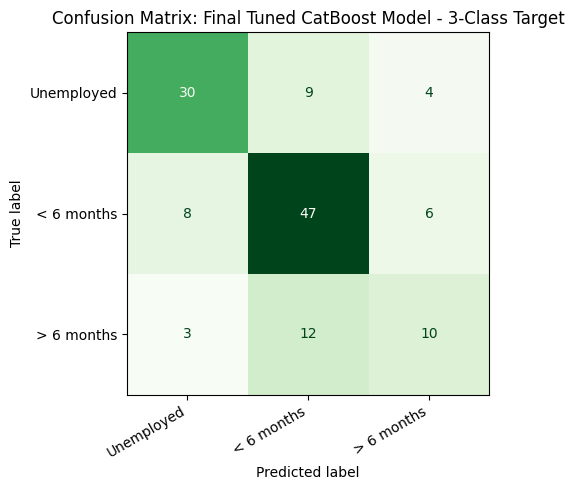

In [ ]:
## 106
## Catboost confusion matrix.
cm_catboost_3 = confusion_matrix(y_3_model, y_3_pred_catboost_cv)

disp_catboost_3 = ConfusionMatrixDisplay(
    confusion_matrix=cm_catboost_3,
    display_labels=target_names_3
)

fig, ax = plt.subplots(figsize=(7, 5))
disp_catboost_3.plot(ax=ax, cmap="Greens", colorbar=False)

plt.title("Confusion Matrix: Final Tuned CatBoost Model - 3-Class Target")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
## 107
# Final ordered comparison of tuned 3-class models

final_3class_models = [
    {
        "model": "XGBoost - 3-class reduced",
        "estimator": xgb_3_final_clean
    },
    {
        "model": "Random Forest - 3-class reduced",
        "estimator": rf_3_final_clean
    },
    {
        "model": "CatBoost - 3-class reduced",
        "estimator": catboost_3_final_clean
    }
]

final_3class_cv_results = []

for item in final_3class_models:

    pipeline = ImbPipeline(steps=[
        ("preprocessor", build_preprocessor(X_3_reduced)),
        ("oversampler", RandomOverSampler(random_state=42)),
        ("model", item["estimator"])
    ])

    scores = cross_validate(
        pipeline,
        X_3_reduced,
        y_3_model,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    final_3class_cv_results.append({
        "model": item["model"],
        "accuracy_mean": scores["test_accuracy"].mean(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "weighted_f1_mean": scores["test_weighted_f1"].mean()
    })

final_3class_cv_results_df = pd.DataFrame(final_3class_cv_results)

final_3class_cv_results_df = final_3class_cv_results_df.sort_values(
    by="macro_f1_mean",
    ascending=False
)

final_3class_cv_results_df

,model,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,weighted_f1_mean
2,CatBoost - 3-class reduced,0.708308,0.655043,0.660150,0.693696
0,XGBoost - 3-class reduced,0.682215,0.634336,0.637345,0.672273
1,Random Forest - 3-class reduced,0.644738,0.598011,0.598723,0.635116
